## Load NC File

### Subtask:
Load the provided NC file, '/content/f12_20060124v7.nc', into a suitable data structure using a library like xarray to access its contents.


**Reasoning**:
First, I'll import the xarray library, define the file path, and then use xarray's open_dataset function to load the NC file into a dataset.



<xarray.Dataset> Size: 4MB
Dimensions:  (lat: 720, lon: 1440)
Coordinates:
  * lat      (lat) float64 6kB -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * lon      (lon) float64 12kB 0.125 0.375 0.625 0.875 ... 359.4 359.6 359.9
Data variables:
    sst      (lat, lon) float32 4MB ...
Attributes:
    title:    TMI Ascending Pass SST
Data Variables: Data variables:
    sst      (lat, lon) float32 4MB ...
Coordinates: Coordinates:
  * lat      (lat) float64 6kB -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * lon      (lon) float64 12kB 0.125 0.375 0.625 0.875 ... 359.4 359.6 359.9
Dimensions: FrozenMappingWarningOnValuesAccess({'lat': 720, 'lon': 1440})


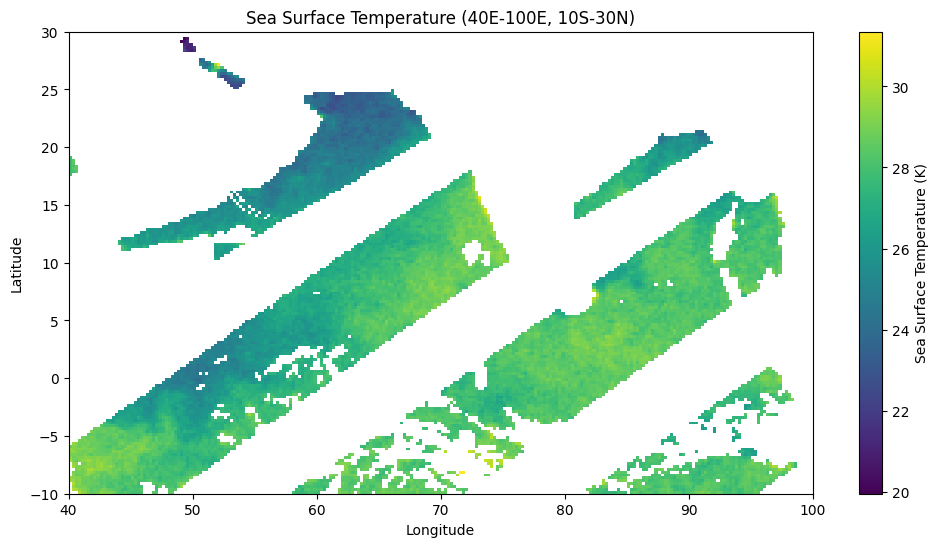

In [ ]:
import xarray as xr
import matplotlib.pyplot as plt

# File path
file_path = '/content/drive/MyDrive/TMIDATA/f12_20060124v7.nc'
file2_Path = '/content/drive/MyDrive/AquaModis/AQUA_MODIS.20060124.L3m.DAY.SST.sst.4km.nc'

# Open dataset
ds = xr.open_dataset(file_path)

print(ds)
print("Data Variables:", ds.data_vars)
print("Coordinates:", ds.coords)
print("Dimensions:", ds.dims)

# Subset region: 40E–100E, 10S–30N
ds_region = ds.sel(lon=slice(40, 100), lat=slice(-10, 30))

# Define vmin and vmax based on the data
vmin = ds_region['sst'].min().item()
vmax = ds_region['sst'].max().item()

# Plot SST with viridis colormap and fixed colorbar
plt.figure(figsize=(12, 6))
ds_region['sst'].plot(
    vmin=vmin,       # colorbar min
    vmax=vmax,       # colorbar max
    cmap='viridis',           # colormap
    cbar_kwargs={'label': 'Sea Surface Temperature (K)'}
)
plt.title('Sea Surface Temperature (40E-100E, 10S-30N)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

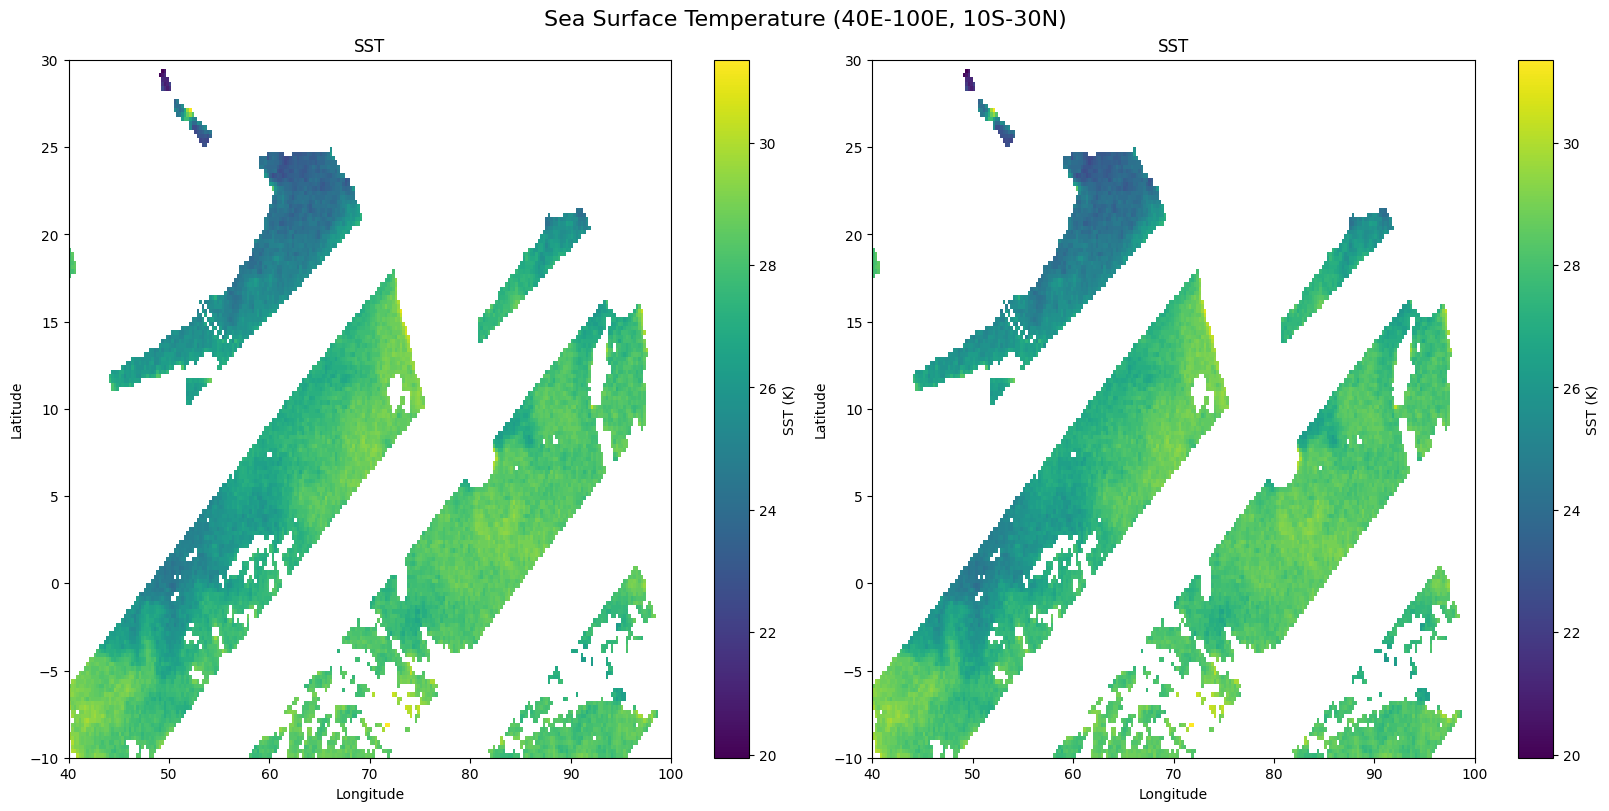

In [ ]:
import xarray as xr
import matplotlib.pyplot as plt

# File paths
file_path = '/content/drive/MyDrive/TMIDATA/f12_20060124v7.nc'
file2_Path = '/content/drive/MyDrive/AquaModis/AQUA_MODIS.20060124.L3m.DAY.SST.sst.4km.nc'

# Open dataset
ds = xr.open_dataset(file_path)

# Subset region: 40E–100E, 10S–30N
ds_region = ds.sel(lon=slice(40, 100), lat=slice(-10, 30))

# Define common vmin and vmax for consistent color scale
vmin = ds_region['sst'].min().item()
vmax = ds_region['sst'].max().item()

# If there is a 'time' dimension, select first 4 timesteps (adjust if fewer)
time_steps = ds_region['time'].values[:4] if 'time' in ds_region.dims else [None]*4

# Create a 2x2 grid
fig, axes = plt.subplots(1, 2, figsize=(16, 8), constrained_layout=True)

for i, ax in enumerate(axes.flat):
    if time_steps[i] is not None:
        ds_region['sst'].sel(time=time_steps[i]).plot(
            ax=ax, vmin=vmin, vmax=vmax, cmap='viridis',
            cbar_kwargs={'label': 'SST (K)'}
        )
        ax.set_title(f'Time: {np.datetime_as_string(time_steps[i], unit="D")}')
    else:
        # If no time dimension, just plot the single data
        ds_region['sst'].plot(
            ax=ax, vmin=vmin, vmax=vmax, cmap='viridis',
            cbar_kwargs={'label': 'SST (K)'}
        )
        ax.set_title('SST')

    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

plt.suptitle('Sea Surface Temperature (40E-100E, 10S-30N)', fontsize=16)
plt.show()

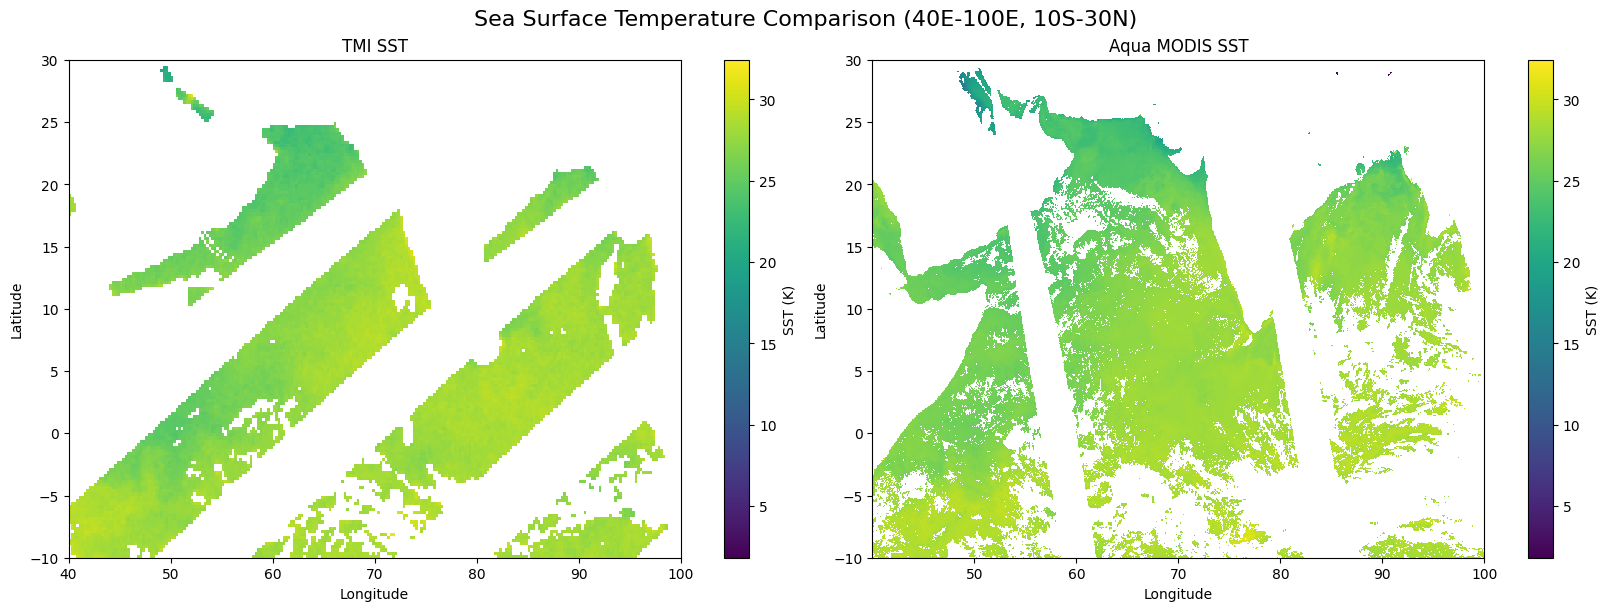

In [3]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

# File paths
file_path = '/content/drive/MyDrive/TMIDATA/f12_20060124v7.nc'
file2_Path = '/content/drive/MyDrive/AquaModis/AQUA_MODIS.20060124.L3m.DAY.SST.sst.4km.nc'

# Open datasets
ds_tmi = xr.open_dataset(file_path)
ds_modis = xr.open_dataset(file2_Path)

# Ensure longitudes are 0–360
ds_tmi = ds_tmi.assign_coords(lon=((ds_tmi.lon + 360) % 360))
ds_modis = ds_modis.assign_coords(lon=((ds_modis.lon + 360) % 360))

# Subset region: 40E–100E, 10S–30N using boolean indexing
lon_mask_tmi = (ds_tmi.lon >= 40) & (ds_tmi.lon <= 100)
lat_mask_tmi = (ds_tmi.lat >= -10) & (ds_tmi.lat <= 30)
ds_tmi_region = ds_tmi.where(lon_mask_tmi & lat_mask_tmi, drop=True)

lon_mask_modis = (ds_modis.lon >= 40) & (ds_modis.lon <= 100)
lat_mask_modis = (ds_modis.lat >= -10) & (ds_modis.lat <= 30)
ds_modis_region = ds_modis.where(lon_mask_modis & lat_mask_modis, drop=True)

# Check if subsets are empty
if ds_tmi_region['sst'].size == 0:
    raise ValueError("TMI subset region is empty. Check latitude and longitude ranges in the dataset.")
if ds_modis_region['sst'].size == 0:
    raise ValueError("Aqua MODIS subset region is empty. Check latitude and longitude ranges in the dataset.")

# Find common color scale across both datasets
vmin = min(np.nanmin(ds_tmi_region['sst'].values), np.nanmin(ds_modis_region['sst'].values))
vmax = max(np.nanmax(ds_tmi_region['sst'].values), np.nanmax(ds_modis_region['sst'].values))

# Create 1x2 grid for comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

# Plot TMI SST
ds_tmi_region['sst'].plot(
    ax=axes[0], vmin=vmin, vmax=vmax, cmap='viridis',
    cbar_kwargs={'label': 'SST (K)'}
)
axes[0].set_title('TMI SST')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')

# Plot Aqua MODIS SST
ds_modis_region['sst'].plot(
    ax=axes[1], vmin=vmin, vmax=vmax, cmap='viridis',
    cbar_kwargs={'label': 'SST (K)'}
)
axes[1].set_title('Aqua MODIS SST')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')

plt.suptitle('Sea Surface Temperature Comparison (40E-100E, 10S-30N)', fontsize=16)
plt.show()

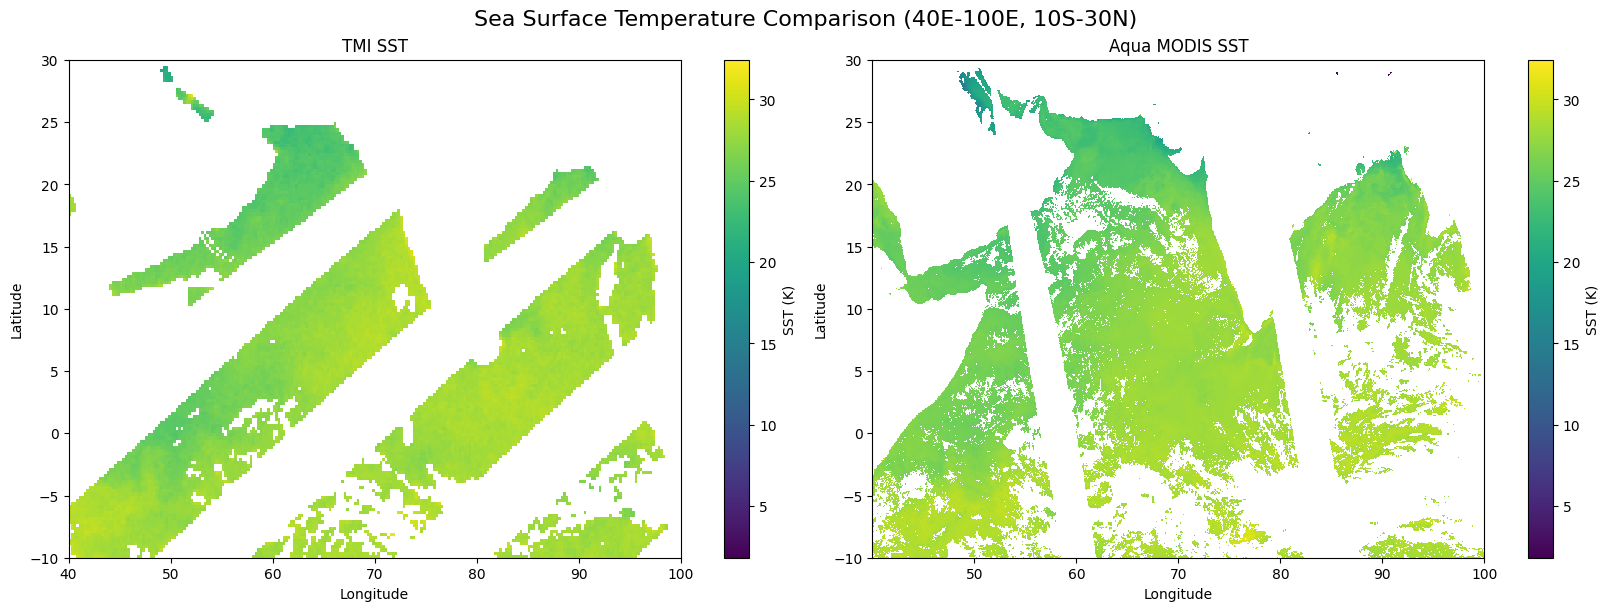

In [ ]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

# -------------------------------
# File paths
# -------------------------------
file_tmi = '/content/drive/MyDrive/TMIDATA/f12_20060124v7.nc'
file_modis = '/content/drive/MyDrive/AquaModis/AQUA_MODIS.20060124.L3m.DAY.SST.sst.4km.nc'
sac123

# -------------------------------
# Open datasets
# -------------------------------
ds_tmi = xr.open_dataset(file_tmi)
ds_modis = xr.open_dataset(file_modis)

# -------------------------------
# Ensure longitudes are 0–360
# -------------------------------
ds_tmi = ds_tmi.assign_coords(lon=((ds_tmi.lon + 360) % 360))
ds_modis = ds_modis.assign_coords(lon=((ds_modis.lon + 360) % 360))

# -------------------------------
# Subset region using boolean indexing
# -------------------------------
lon_mask_tmi = (ds_tmi.lon >= 40) & (ds_tmi.lon <= 100)
lat_mask_tmi = (ds_tmi.lat >= -10) & (ds_tmi.lat <= 30)
ds_tmi_region = ds_tmi.where(lon_mask_tmi & lat_mask_tmi, drop=True)

lon_mask_modis = (ds_modis.lon >= 40) & (ds_modis.lon <= 100)
lat_mask_modis = (ds_modis.lat >= -10) & (ds_modis.lat <= 30)
ds_modis_region = ds_modis.where(lon_mask_modis & lat_mask_modis, drop=True)

# -------------------------------
# Check if subsets are empty
# -------------------------------
if ds_tmi_region['sst'].size == 0 or ds_modis_region['sst'].size == 0:
    raise ValueError("Subset region is empty. Check latitude and longitude ranges in the datasets.")

# -------------------------------
# Define common color scale
# -------------------------------
vmin = min(np.nanmin(ds_tmi_region['sst'].values), np.nanmin(ds_modis_region['sst'].values))
vmax = max(np.nanmax(ds_tmi_region['sst'].values), np.nanmax(ds_modis_region['sst'].values))

# -------------------------------
# Create 1x2 grid plot
# -------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

# TMI SST
ds_tmi_region['sst'].plot(
    ax=axes[0], vmin=vmin, vmax=vmax, cmap='viridis',
    cbar_kwargs={'label': 'SST (K)'}
)
axes[0].set_title('TMI SST')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')

# Aqua MODIS SST
ds_modis_region['sst'].plot(
    ax=axes[1], vmin=vmin, vmax=vmax, cmap='viridis',
    cbar_kwargs={'label': 'SST (K)'}
)
axes[1].set_title('Aqua MODIS SST')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')

# Overall title
plt.suptitle('Sea Surface Temperature Comparison (40E-100E, 10S-30N)', fontsize=16)
plt.show()

In [ ]:
import xarray as xr

file_path = '/content/drive/MyDrive/TMIDATA/f12_20060124v7.nc'
ds = xr.open_dataset(file_path)

print(ds)

<xarray.Dataset> Size: 4MB
Dimensions:  (lat: 720, lon: 1440)
Coordinates:
  * lat      (lat) float64 6kB -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * lon      (lon) float64 12kB 0.125 0.375 0.625 0.875 ... 359.4 359.6 359.9
Data variables:
    sst      (lat, lon) float32 4MB ...
Attributes:
    title:    TMI Ascending Pass SST


## Identify Datasets

### Subtask:
Examine the loaded NC file to identify the available variables or datasets that can be plotted. This step involves listing the dimensions, coordinates, and data variables within the file.


**Reasoning**:
To identify the available variables, coordinates, and dimensions, I will access the `data_vars`, `coords`, and `dims` attributes of the loaded `ds` xarray Dataset and print them.



In [ ]:
print("Data Variables:", ds.data_vars)
print("Coordinates:", ds.coords)
print("Dimensions:", ds.dims)

Data Variables: Data variables:
    sst      (lat, lon) float32 4MB ...
Coordinates: Coordinates:
  * lat      (lat) float64 6kB -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * lon      (lon) float64 12kB 0.125 0.375 0.625 0.875 ... 359.4 359.6 359.9
Dimensions: FrozenMappingWarningOnValuesAccess({'lat': 720, 'lon': 1440})


## Plot Datasets

### Subtask:
Generate appropriate plots for the identified datasets. This may involve selecting specific variables, applying filtering or aggregation if necessary, and choosing suitable visualization types (e.g., line plots, contour plots, heatmaps) with legends.


**Reasoning**:
To visualize the 'sst' data, I will import `matplotlib.pyplot` and then use xarray's built-in `.plot()` method on the 'sst' data variable, adding a title and colorbar for clarity, and finally display the plot.



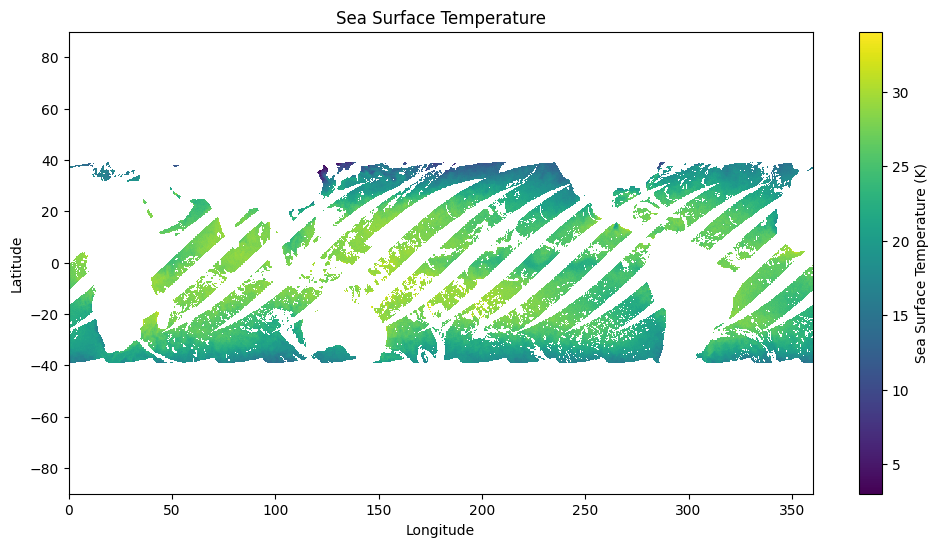

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
ds['sst'].plot(cbar_kwargs={'label': 'Sea Surface Temperature (K)'})
plt.title('Sea Surface Temperature')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

In [ ]:
import xarray as xr

file_path = '/content/drive/MyDrive/AquaModis/AQUA_MODIS.20060124.L3m.DAY.SST.sst.4km.nc'
ds = xr.open_dataset(file_path)

print(ds)
print("Data Variables:", ds.data_vars)
print("Coordinates:", ds.coords)
print("Dimensions:", ds.dims)


<xarray.Dataset> Size: 299MB
Dimensions:   (lat: 4320, lon: 8640, rgb: 3, eightbitcolor: 256)
Coordinates:
  * lat       (lat) float32 17kB 89.98 89.94 89.9 89.85 ... -89.9 -89.94 -89.98
  * lon       (lon) float32 35kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
Dimensions without coordinates: rgb, eightbitcolor
Data variables:
    sst       (lat, lon) float32 149MB ...
    qual_sst  (lat, lon) float32 149MB ...
    palette   (rgb, eightbitcolor) uint8 768B ...
Attributes: (12/61)
    product_name:                     AQUA_MODIS.20060124.L3m.DAY.SST.sst.4km.nc
    instrument:                       MODIS
    title:                            MODISA Level-3 Standard Mapped Image
    project:                          Ocean Biology Processing Group (NASA/GS...
    platform:                         Aqua
    temporal_range:                   day
    ...                               ...
    cdm_data_type:                    grid
    keywords:                         Earth Science > Oceans > 

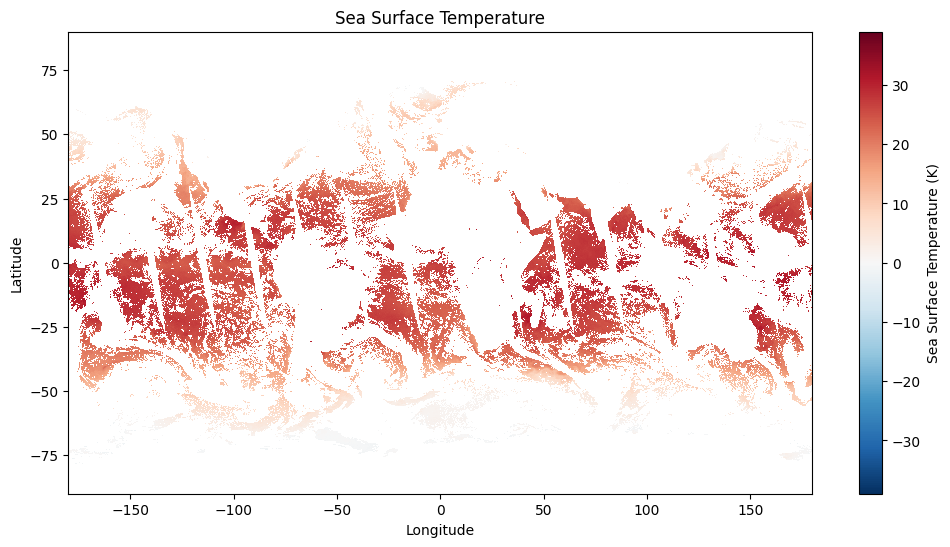

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
ds['sst'].plot(cbar_kwargs={'label': 'Sea Surface Temperature (K)'})
plt.title('Sea Surface Temperature')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

In [ ]:
  import xarray as xr

file_path = '/content/drive/MyDrive/fsleDATA/dt_global_allsat_madt_fsle_20060124_20250404.nc'
ds = xr.open_dataset(file_path)

print(ds)
print("Data Variables:", ds.data_vars)
print("Coordinates:", ds.coords)
print("Dimensions:", ds.dims)


<xarray.Dataset> Size: 324MB
Dimensions:    (lat: 4500, nv: 2, lon: 9000, time: 1)
Coordinates:
  * lat        (lat) float32 18kB -89.98 -89.94 -89.9 ... 89.9 89.94 89.98
  * nv         (nv) int32 8B 0 1
  * lon        (lon) float32 36kB 0.02 0.06 0.1 0.14 ... 359.9 359.9 359.9 360.0
  * time       (time) datetime64[ns] 8B 2006-01-24
Data variables:
    crs        int32 4B ...
    lat_bnds   (lat, nv) float32 36kB ...
    lon_bnds   (lon, nv) float32 72kB ...
    fsle_max   (time, lat, lon) float32 162MB ...
    theta_max  (time, lat, lon) float32 162MB ...
Attributes: (12/27)
    cdm_data_type:              Grid
    Conventions:                CF-1.6
    standard_name_vocabulary:   NetCDF Climate and Forecast (CF) Metadata Con...
    title:                      Backward-in-time, finite-size Lyapunov expone...
    summary:                    This dataset contains Backward-in-time FSLE p...
    separation:                 Initial separation in degrees: 0.02; Maximal ...
    ...         

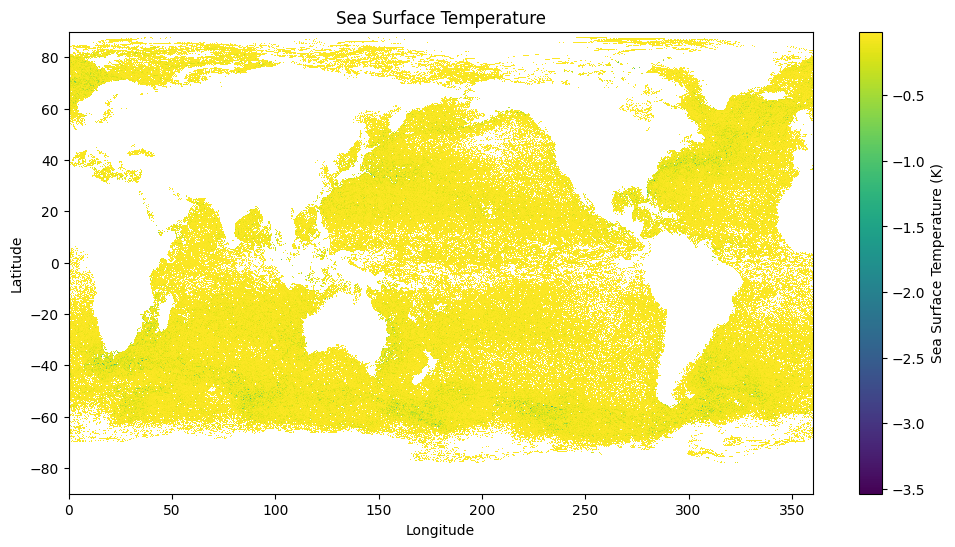

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
ds['fsle_max'].plot(cbar_kwargs={'label': 'Sea Surface Temperature (K)'})
plt.title('Sea Surface Temperature')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

<xarray.Dataset> Size: 75kB
Dimensions:   (lat: 96, lon: 96)
Coordinates:
  * lat       (lat) float64 768B 7.875 7.917 7.959 8.001 ... 11.79 11.83 11.88
  * lon       (lon) float64 768B 63.88 63.92 63.96 64.0 ... 67.79 67.83 67.88
    time      datetime64[ns] 8B ...
Data variables:
    fsle_max  (lat, lon) float64 74kB ...
Data Variables: Data variables:
    fsle_max  (lat, lon) float64 74kB ...
Coordinates: Coordinates:
  * lat      (lat) float64 768B 7.875 7.917 7.959 8.001 ... 11.79 11.83 11.88
  * lon      (lon) float64 768B 63.88 63.92 63.96 64.0 ... 67.79 67.83 67.88
    time     datetime64[ns] 8B ...
Dimensions: FrozenMappingWarningOnValuesAccess({'lat': 96, 'lon': 96})


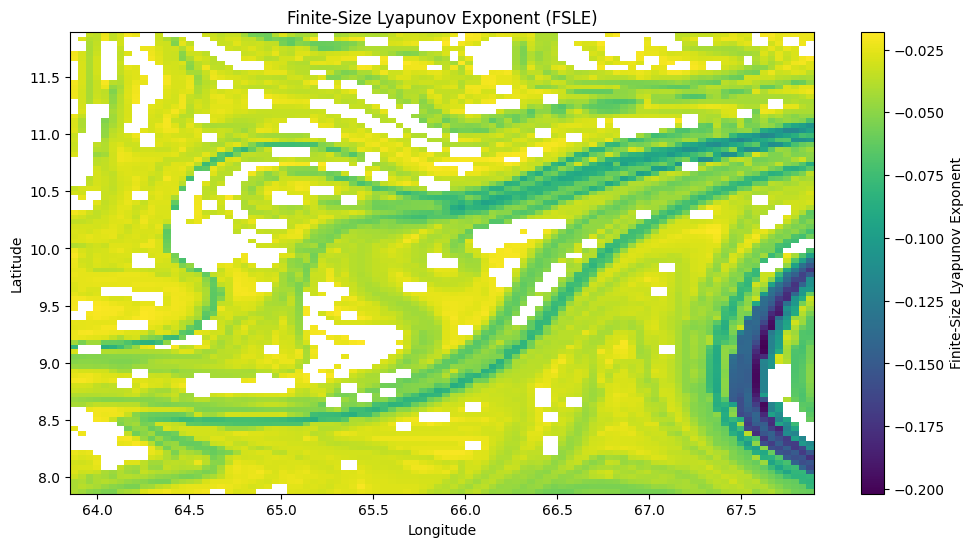

In [ ]:
import xarray as xr

file_path = '/content/drive/MyDrive/2026/Patches/fsle/extracted_391_255_f12_20060124v7_fsle.nc'
ds = xr.open_dataset(file_path)

print(ds)
print("Data Variables:", ds.data_vars)
print("Coordinates:", ds.coords)
print("Dimensions:", ds.dims)
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
ds['fsle_max'].plot(cbar_kwargs={'label': 'Finite-Size Lyapunov Exponent'}) # Changed 'sst' to 'fsle_max' and updated label
plt.title('Finite-Size Lyapunov Exponent (FSLE)') # Updated title
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


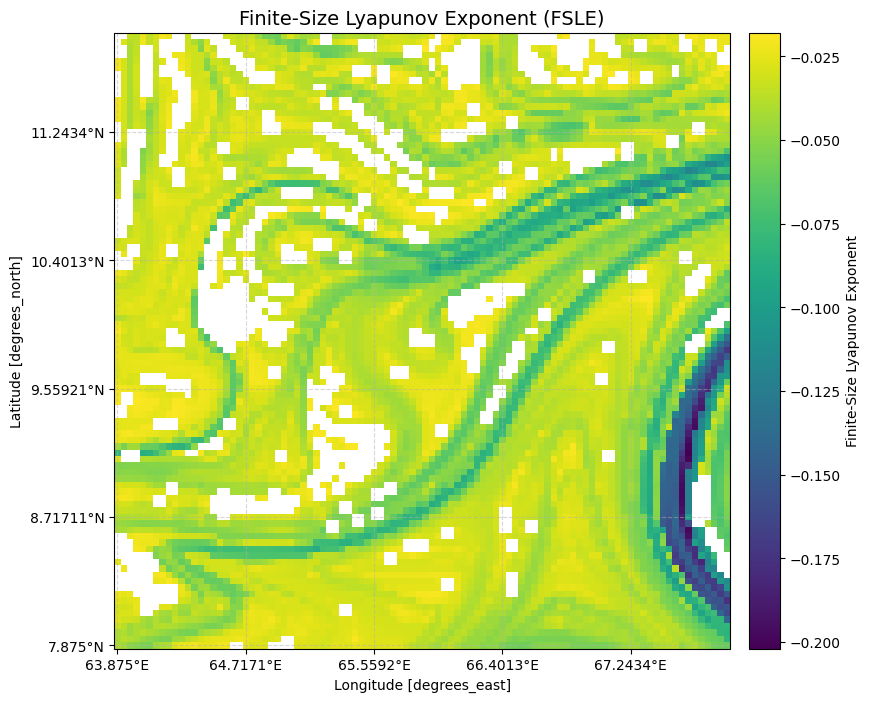

In [ ]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy.mpl.ticker import LatitudeFormatter, LongitudeFormatter

# 1. Load data
file_path = '/content/drive/MyDrive/2026/Patches/fsle/extracted_391_255_f12_20060124v7_fsle.nc'
ds = xr.open_dataset(file_path)

# 2. Setup the figure with a projection
plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# 3. Plot using xarray's .plot()
# We specify transform=ccrs.PlateCarree() so the data is mapped correctly
ds['fsle_max'].plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={'label': 'Finite-Size Lyapunov Exponent', 'pad': 0.02}
)

# 4. Add Coastlines for context
ax.coastlines()

# 5. Format Lat/Lon labels to show N/S and E/W
ax.set_xticks(ds.lon.values[::20], crs=ccrs.PlateCarree()) # Adjust slicing [::20] for density
ax.set_yticks(ds.lat.values[::20], crs=ccrs.PlateCarree())

lon_formatter = LongitudeFormatter()
lat_formatter = LatitudeFormatter()

ax.xaxis.set_major_formatter(lon_formatter)
ax.yaxis.set_major_formatter(lat_formatter)

# 6. Final Polish
plt.title('Finite-Size Lyapunov Exponent (FSLE)', fontsize=14)
plt.grid(linestyle='--', alpha=0.5)
plt.show()

<xarray.Dataset> Size: 75kB
Dimensions:  (lat: 96, lon: 96)
Coordinates:
  * lat      (lat) float64 768B 7.875 7.917 7.959 8.001 ... 11.79 11.83 11.88
  * lon      (lon) float64 768B 63.88 63.92 63.96 64.0 ... 67.79 67.83 67.88
Data variables:
    sst      (lat, lon) float64 74kB ...
Data Variables: Data variables:
    sst      (lat, lon) float64 74kB ...
Coordinates: Coordinates:
  * lat      (lat) float64 768B 7.875 7.917 7.959 8.001 ... 11.79 11.83 11.88
  * lon      (lon) float64 768B 63.88 63.92 63.96 64.0 ... 67.79 67.83 67.88
Dimensions: FrozenMappingWarningOnValuesAccess({'lat': 96, 'lon': 96})


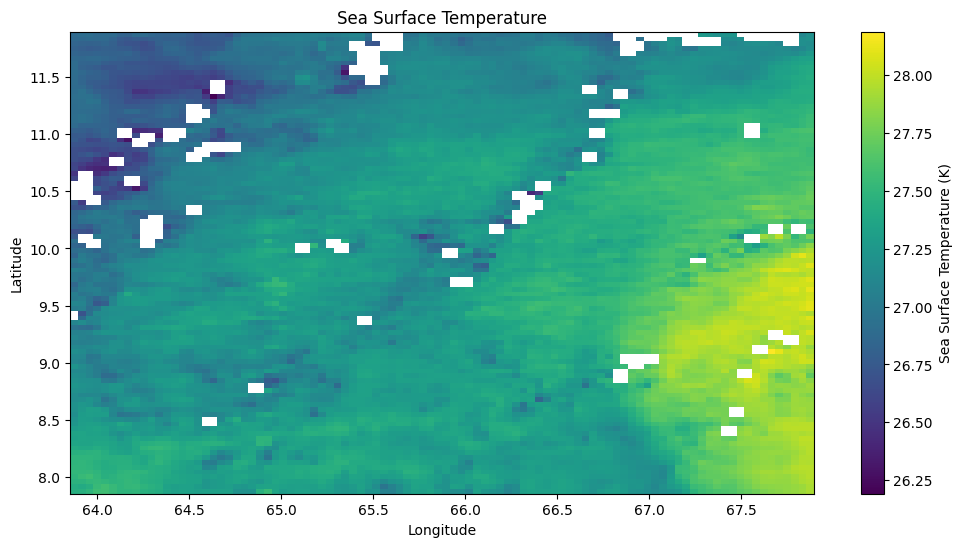

In [ ]:
import xarray as xr

file_path = '/content/drive/MyDrive/2026/Patches/aqua/extracted_391_255_20060124.nc'
ds = xr.open_dataset(file_path)

print(ds)

print("Data Variables:", ds.data_vars)
print("Coordinates:", ds.coords)
print("Dimensions:", ds.dims)

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
ds['sst'].plot(cbar_kwargs={'label': 'Sea Surface Temperature (K)'})
plt.title('Sea Surface Temperature')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

In [ ]:
tmi_ds = xr.open_dataset('/content/drive/MyDrive/TMIDATA/f12_20060124v7.nc')
print("TMI Dataset:")
print(tmi_ds)

aqua_ds = xr.open_dataset('/content/drive/MyDrive/AquaModis/AQUA_MODIS.20060124.L3m.DAY.SST.sst.4km.nc')
print("\nAqua MODIS Dataset:")
print(aqua_ds)

fsle_ds = xr.open_dataset('/content/drive/MyDrive/fsleDATA/dt_global_allsat_madt_fsle_20060124_20250404.nc')
print("\nFSLE Dataset:")
print(fsle_ds)

print("\n--- Dataset Coordinate Ranges ---")

# TMI Dataset
print("\nTMI Dataset (tmi_ds):")
print(f"  Latitude Range: {tmi_ds['lat'].min().item():.2f} to {tmi_ds['lat'].max().item():.2f}")
print(f"  Longitude Range: {tmi_ds['lon'].min().item():.2f} to {tmi_ds['lon'].max().item():.2f}")

# Aqua MODIS Dataset
print("\nAqua MODIS Dataset (aqua_ds):")
print(f"  Latitude Range: {aqua_ds['lat'].min().item():.2f} to {aqua_ds['lat'].max().item():.2f}")
print(f"  Longitude Range: {aqua_ds['lon'].min().item():.2f} to {aqua_ds['lon'].max().item():.2f}")

# FSLE Dataset
print("\nFSLE Dataset (fsle_ds):")
print(f"  Latitude Range: {fsle_ds['lat'].min().item():.2f} to {fsle_ds['lat'].max().item():.2f}")
print(f"  Longitude Range: {fsle_ds['lon'].min().item():.2f} to {fsle_ds['lon'].max().item():.2f}")

TMI Dataset:
<xarray.Dataset> Size: 4MB
Dimensions:  (lat: 720, lon: 1440)
Coordinates:
  * lat      (lat) float64 6kB -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * lon      (lon) float64 12kB 0.125 0.375 0.625 0.875 ... 359.4 359.6 359.9
Data variables:
    sst      (lat, lon) float32 4MB ...
Attributes:
    title:    TMI Ascending Pass SST

Aqua MODIS Dataset:
<xarray.Dataset> Size: 299MB
Dimensions:   (lat: 4320, lon: 8640, rgb: 3, eightbitcolor: 256)
Coordinates:
  * lat       (lat) float32 17kB 89.98 89.94 89.9 89.85 ... -89.9 -89.94 -89.98
  * lon       (lon) float32 35kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
Dimensions without coordinates: rgb, eightbitcolor
Data variables:
    sst       (lat, lon) float32 149MB ...
    qual_sst  (lat, lon) float32 149MB ...
    palette   (rgb, eightbitcolor) uint8 768B ...
Attributes: (12/61)
    product_name:                     AQUA_MODIS.20060124.L3m.DAY.SST.sst.4km.nc
    instrument:                       MODIS
    title:      